In [2]:
import zipfile, os

zip_path = "/content/images.zip"
extract_dir = "/content/images"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

print("Extracted folders:", os.listdir(extract_dir))

Extracted folders: ['images']


In [3]:
import os
data_dir = "/content/images/images"
print(os.listdir(data_dir))

['pizza', 'soccer_ball', 'dalmatian', 'dollar_bill', 'sunflower']


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.io import imread
from skimage.transform import resize

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
import os
print(sorted(os.listdir("/content/images/images")))

['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']


## Load images + preprocess

In [6]:
def load_image_files(container_path, dimension=(64, 64)):
    image_dir = container_path

    # class folders (each folder = one class)
    folders = sorted([d for d in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, d))])
    target_names = folders

    X = []
    y = []

    for i, class_name in enumerate(folders):
        class_path = os.path.join(image_dir, class_name)
        for file_name in sorted(os.listdir(class_path)):
            file_path = os.path.join(class_path, file_name)

            # read image (colored -> usually HxWx3)
            img = imread(file_path)
            img_resized = resize(img, dimension, anti_aliasing=True, mode='reflect')

            # normalize to [0,1] if needed
            img_resized = img_resized.astype(np.float32)
            if img_resized.max() > 1.0:
                img_resized /= 255.0

            X.append(img_resized.flatten())
            y.append(i)

    return np.array(X), np.array(y), target_names

X, y, target_names = load_image_files("/content/images/images", dimension=(64, 64))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", target_names)

X shape: (309, 12288)
y shape: (309,)
Classes: ['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']


## Split into train/test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=109
)

## Random Forest + GridSearchCV

In [8]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='accuracy'
)

grid_rf.fit(X_train, y_train)

best_rf_model = grid_rf.best_estimator_
print("Best params:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score: 0.7685185185185185


## Train (best model) and predict

In [9]:
y_pred_rf = best_rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_rf)
print("Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=target_names))

Test Accuracy: 0.7419354838709677

Classification Report:
               precision    recall  f1-score   support

   dalmatian       0.64      0.64      0.64        22
 dollar_bill       0.67      0.71      0.69        17
       pizza       0.91      0.71      0.80        14
 soccer_ball       0.69      0.65      0.67        17
   sunflower       0.85      0.96      0.90        23

    accuracy                           0.74        93
   macro avg       0.75      0.73      0.74        93
weighted avg       0.74      0.74      0.74        93



## Confusion matrix

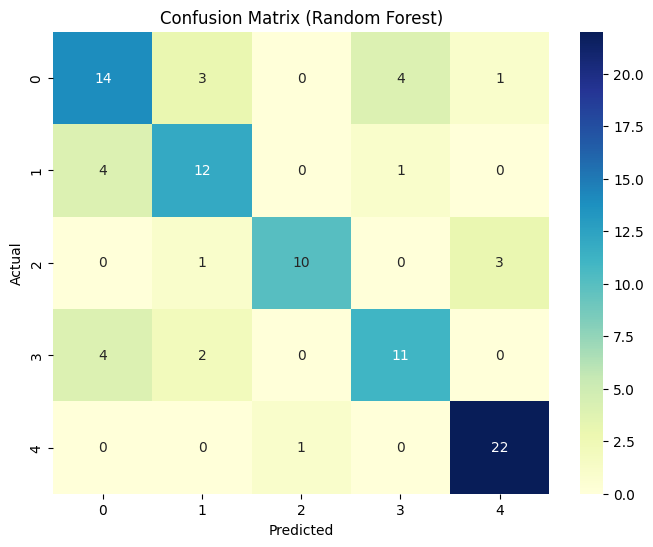

In [10]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest)")
plt.show()

## Feature importance + bar plot

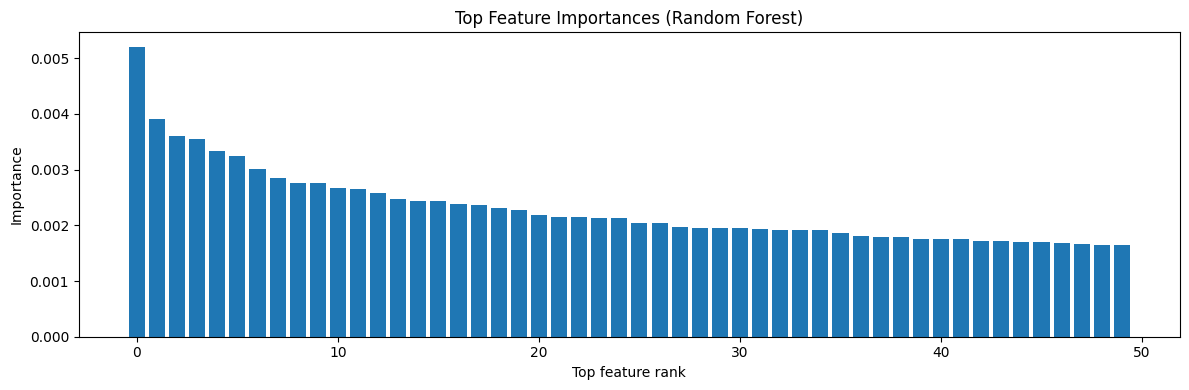

In [11]:
importances = best_rf_model.feature_importances_

# Top N features (pixel positions) to keep the plot readable
N = 50
top_idx = np.argsort(importances)[::-1][:N]
top_importances = importances[top_idx]

plt.figure(figsize=(12, 4))
plt.bar(range(N), top_importances)
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Top feature rank")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Predict on a new image

In [12]:
def predict_new_image(image_path, model, dimension=(64, 64)):
    img = imread(image_path)
    img_resized = resize(img, dimension, anti_aliasing=True, mode='reflect')
    img_resized = img_resized.astype(np.float32)
    if img_resized.max() > 1.0:
        img_resized /= 255.0

    x = img_resized.flatten().reshape(1, -1)
    pred_idx = model.predict(x)[0]
    return target_names[pred_idx]
